### MinMaxScaler Formula

The formula for Min-Max Scaling (Normalization) is:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Where:
*   **$x_{scaled}$**: The rescaled value (typically between 0 and 1)
*   **$x$**: The original value
*   **$x_{min}$**: The minimum value in the feature column
*   **$x_{max}$**: The maximum value in the feature column


In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


array([0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

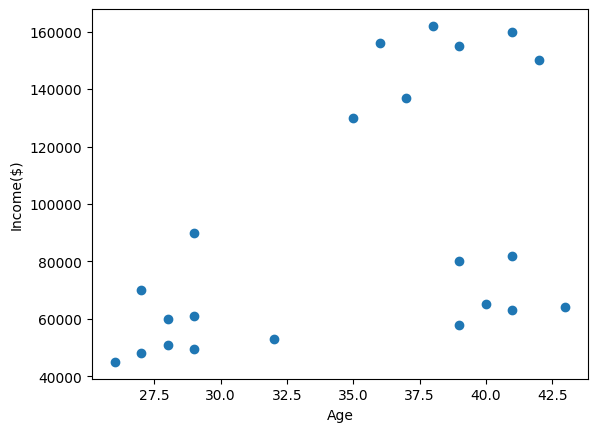

In [3]:
plt.scatter(df.Age, df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income($)')
km = KMeans(n_clusters = 3)
y_pred = km.fit_predict(df[['Age','Income($)']])
y_pred

In [4]:
df['cluster'] = y_pred
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [5]:
km.cluster_centers_

array([[3.32000000e+01, 6.26333333e+04],
       [3.92000000e+01, 1.56600000e+05],
       [3.60000000e+01, 1.33500000e+05]])

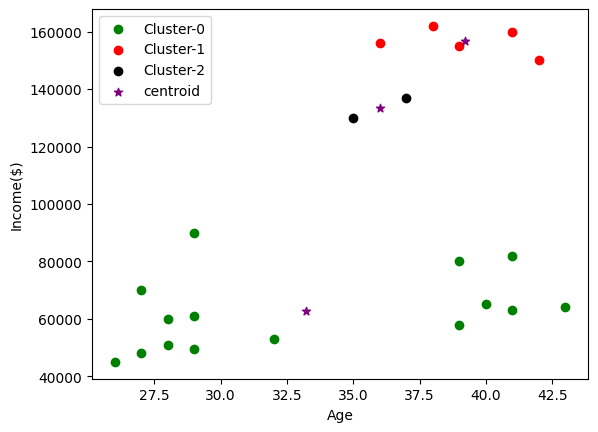

In [6]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age, df1['Income($)'], color = 'green', label = 'Cluster-0')
plt.scatter(df2.Age, df2['Income($)'], color = 'red', label = 'Cluster-1')
plt.scatter(df3.Age, df3['Income($)'], color = 'black', label = 'Cluster-2')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color = 'purple', marker = '*', label = 'centroid')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()

In [7]:
scaler = MinMaxScaler()

In [8]:
scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

In [9]:
scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

In [10]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


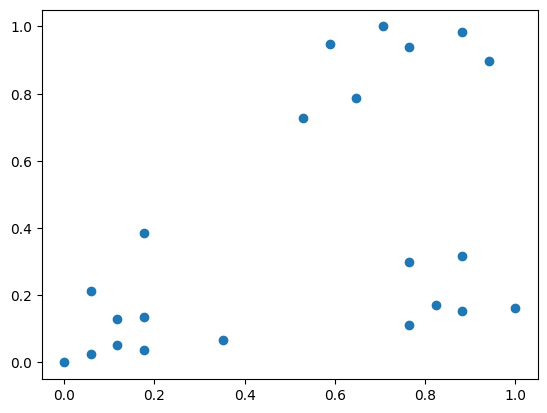

In [11]:
plt.scatter(df.Age, df['Income($)'])

In [12]:
km = KMeans(n_clusters = 3)
y_pred2 = km.fit_predict(df[['Age','Income($)']])
y_pred2
df['cluster'] = y_pred2
df.head()
km.cluster_centers_

array([[0.72268908, 0.8974359 ],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

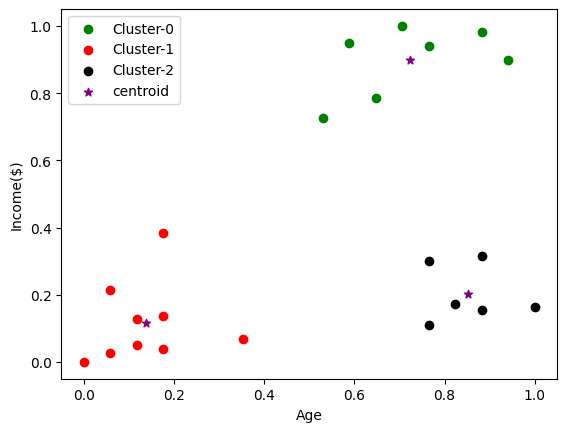

In [13]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age, df1['Income($)'], color = 'green', label = 'Cluster-0')
plt.scatter(df2.Age, df2['Income($)'], color = 'red', label = 'Cluster-1')
plt.scatter(df3.Age, df3['Income($)'], color = 'black', label = 'Cluster-2')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color = 'purple', marker = '*', label = 'centroid')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters = k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)

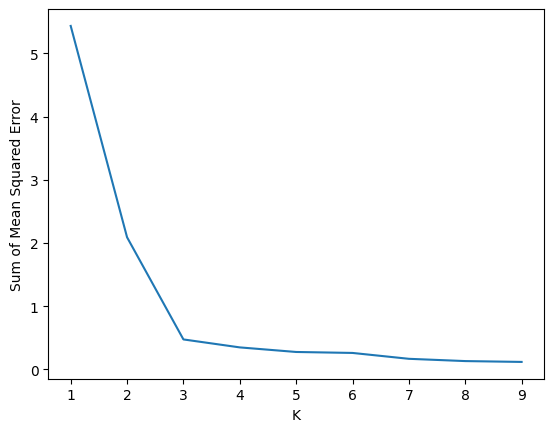

In [14]:
plt.xlabel('K')
plt.ylabel('Sum of Mean Squared Error')
plt.plot(k_rng,sse)